In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [16]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [17]:
df =pd.read_csv(r"C:\Users\SamuelJoshuaRaj\Downloads\job market\disoccupazione.csv")

In [18]:
print(df)

      iso_code      country     sex    age  year  obs_value
0          AFG  Afghanistan   Total    15+  2025     13.351
1          AFG  Afghanistan   Total  15-24  2025     16.785
2          AFG  Afghanistan   Total    25+  2025     11.340
3          AFG  Afghanistan    Male    15+  2025     12.503
4          AFG  Afghanistan    Male  15-24  2025     15.814
...        ...          ...     ...    ...   ...        ...
57514      ZWE     Zimbabwe    Male  15-24  1991     13.765
57515      ZWE     Zimbabwe    Male    25+  1991      2.690
57516      ZWE     Zimbabwe  Female    15+  1991      2.871
57517      ZWE     Zimbabwe  Female  15-24  1991      6.744
57518      ZWE     Zimbabwe  Female    25+  1991      1.093

[57519 rows x 6 columns]


In [19]:
df.tail()

,iso_code,country,sex,age,year,obs_value
57514,ZWE,Zimbabwe,Male,15-24,1991,13.765
57515,ZWE,Zimbabwe,Male,25+,1991,2.690
57516,ZWE,Zimbabwe,Female,15+,1991,2.871
57517,ZWE,Zimbabwe,Female,15-24,1991,6.744
57518,ZWE,Zimbabwe,Female,25+,1991,1.093


In [20]:
df.head()

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57519 entries, 0 to 57518
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   iso_code   57519 non-null  str    
 1   country    57519 non-null  str    
 2   sex        57519 non-null  str    
 3   age        57519 non-null  str    
 4   year       57519 non-null  int64  
 5   obs_value  57519 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 2.6 MB


In [22]:
df.describe()

,year,obs_value
count,57519.000000,57519.000000
mean,2007.964951,10.523688
std,10.082723,10.193656
min,1991.000000,0.027000
25%,1999.000000,3.705000
50%,2008.000000,7.173000
75%,2017.000000,13.804500
max,2025.000000,84.183000


In [23]:
df.isnull().sum()

iso_code     0
country      0
sex          0
age          0
year         0
obs_value    0
dtype: int64

In [24]:
df.shape

(57519, 6)

In [25]:
df.nunique()

iso_code       183
country        183
sex              3
age              3
year            35
obs_value    23344
dtype: int64

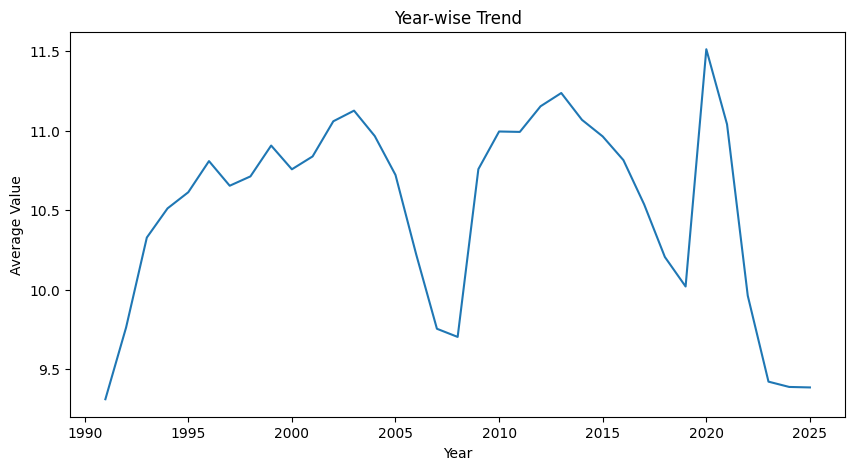

In [26]:
plt.figure(figsize=(10,5))

year_data = df.groupby('year')['obs_value'].mean()

plt.plot(year_data.index, year_data.values)
plt.title("Year-wise Trend")
plt.xlabel("Year")
plt.ylabel("Average Value")

plt.show()

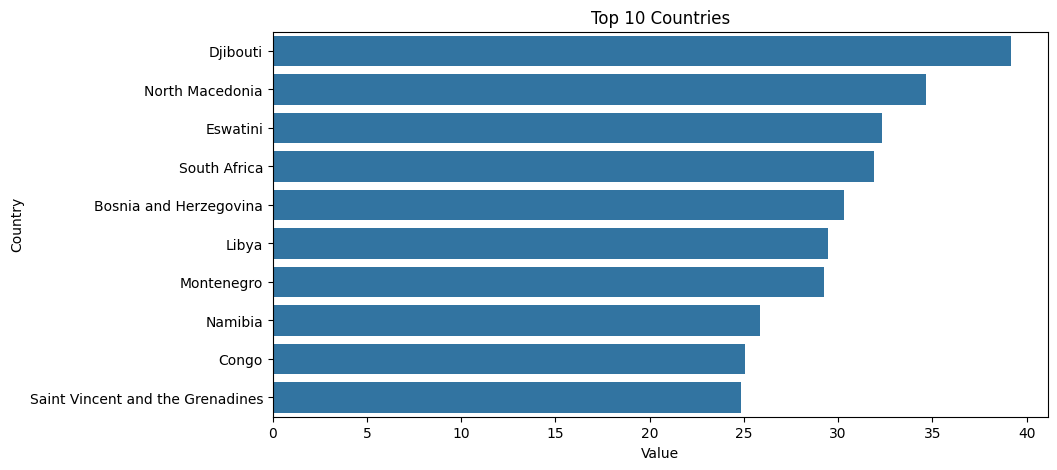

In [27]:
top_countries = df.groupby('country')['obs_value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries")
plt.xlabel("Value")
plt.ylabel("Country")

plt.show()


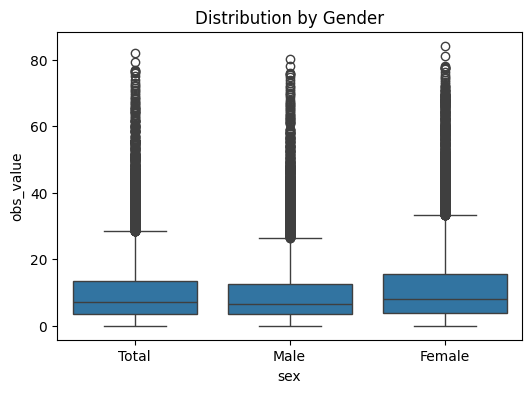

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='obs_value', data=df)

plt.title("Distribution by Gender")
plt.show()

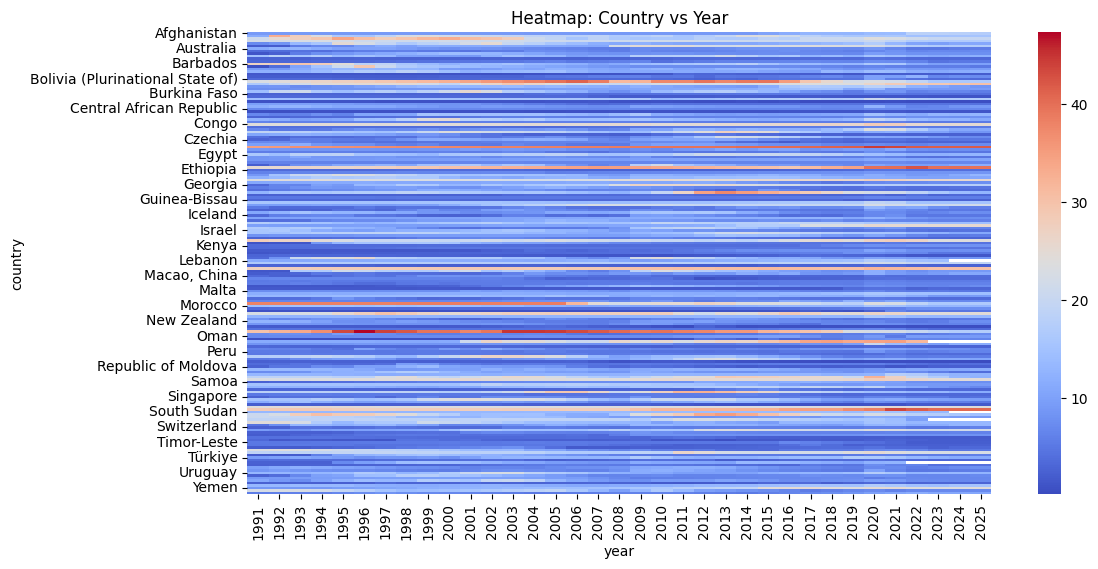

In [29]:
pivot_table = df.pivot_table(values='obs_value', index='country', columns='year')

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='coolwarm')

plt.title("Heatmap: Country vs Year")

plt.show()

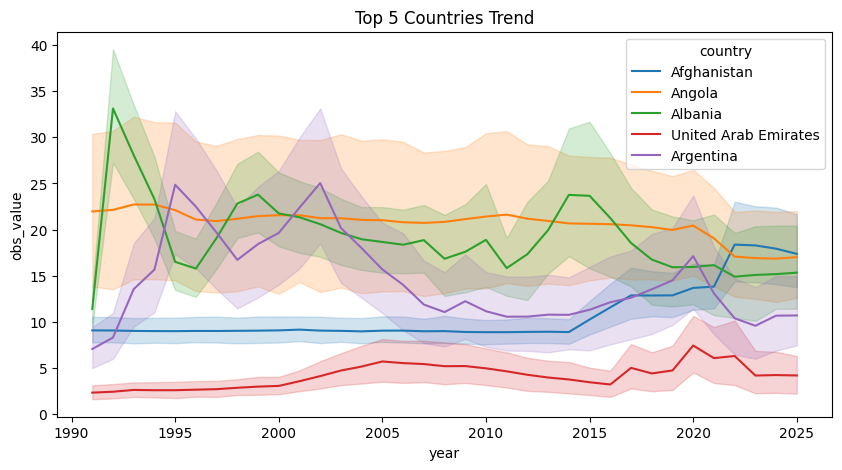

In [30]:
top5 = df['country'].value_counts().head(5).index
filtered = df[df['country'].isin(top5)]

plt.figure(figsize=(10,5))

sns.lineplot(data=filtered, x='year', y='obs_value', hue='country')

plt.title("Top 5 Countries Trend")

plt.show()

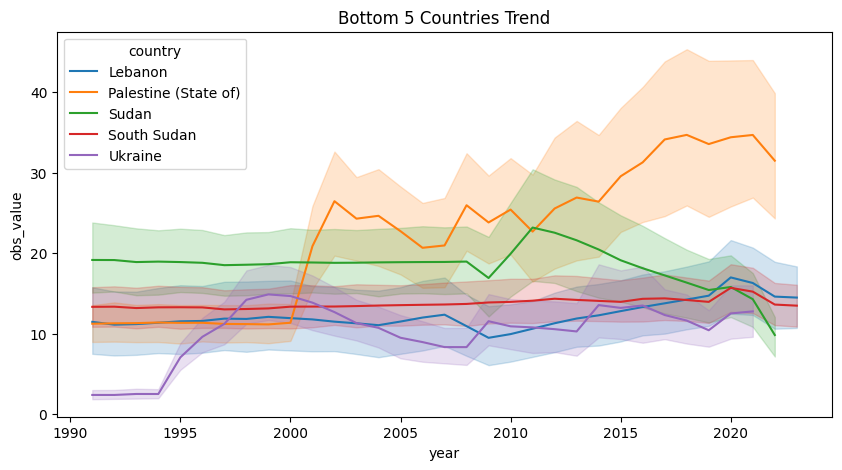

In [31]:
top5 = df['country'].value_counts().tail(5).index
filtered = df[df['country'].isin(top5)]

plt.figure(figsize=(10,5))

sns.lineplot(data=filtered, x='year', y='obs_value', hue='country')

plt.title("Bottom 5 Countries Trend")

plt.show()

In [32]:
df= df.dropna()

In [33]:
df['year'] = df['year'].astype(int)

In [34]:
df = df.sample(5000)

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [38]:
# Example: Above average = 1, Below = 0
threshold = df['obs_value'].mean()

df['target'] = (df['obs_value'] > threshold).astype(int)

In [39]:
X = df[['iso_code', 'country', 'sex', 'age', 'year']]
y = df['target']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [41]:
categorical_cols = ['iso_code', 'country', 'sex', 'age']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])  # no fitting here
    
    encoders[col] = le

In [42]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = {}
roc_data = {}

In [44]:
for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = acc
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)
    
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC Score: {auc:.4f}")
    print("-" * 30)

Logistic Regression
Accuracy: 0.6450
AUC Score: 0.5835
------------------------------
Decision Tree
Accuracy: 0.8580
AUC Score: 0.8462
------------------------------
Random Forest
Accuracy: 0.8540
AUC Score: 0.9112
------------------------------


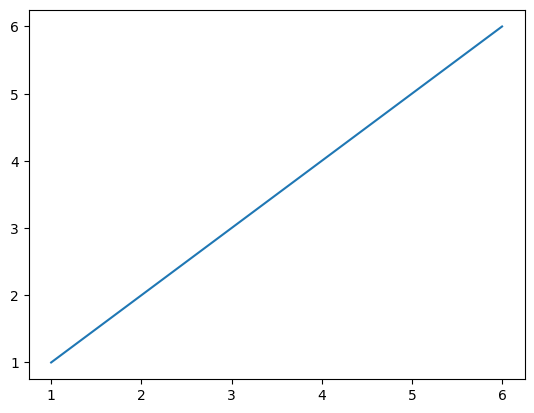

In [2]:
import matplotlib.pyplot as plt

a_x=[1,2,3,4,5,6]
a_y=[1,2,3,4,5,6]

plt.plot(a_x, a_y)
plt.show()

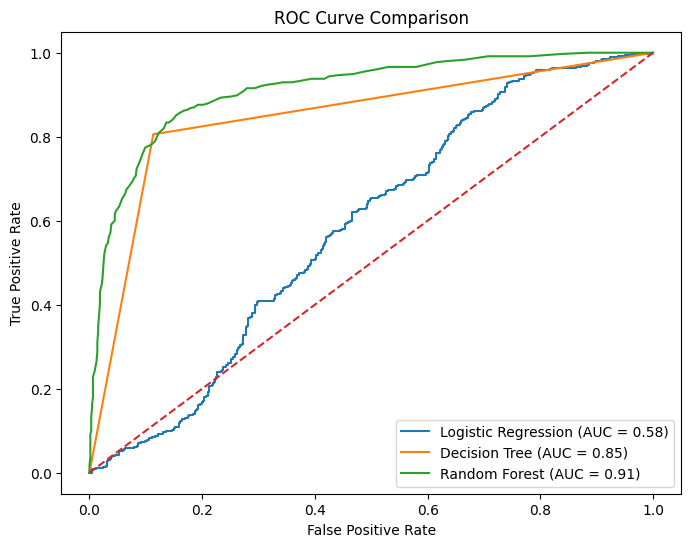

In [45]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [46]:
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.6450
Decision Tree: 0.8580
Random Forest: 0.8540


In [49]:
print("\nFinal Model Accuracy Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


Final Model Accuracy Comparison:
Logistic Regression: 0.6450
Decision Tree: 0.8580
Random Forest: 0.8540


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

best_model = max(results, key=results.get)
best_acc   = results[best_model]
best_auc   = roc_data[best_model][2]

print('=' * 55)
print('        ✅  BEST PERFORMING MODEL')
print('=' * 55)
print(f'  Model     : {best_model}')
print(f'  Accuracy  : {best_acc:.4f}  ({best_acc*100:.2f}%)')
print(f'  AUC Score : {best_auc:.4f}')
print('=' * 55)


        ✅  BEST PERFORMING MODEL
  Model     : Decision Tree
  Accuracy  : 0.8580  (85.80%)
  AUC Score : 0.8462


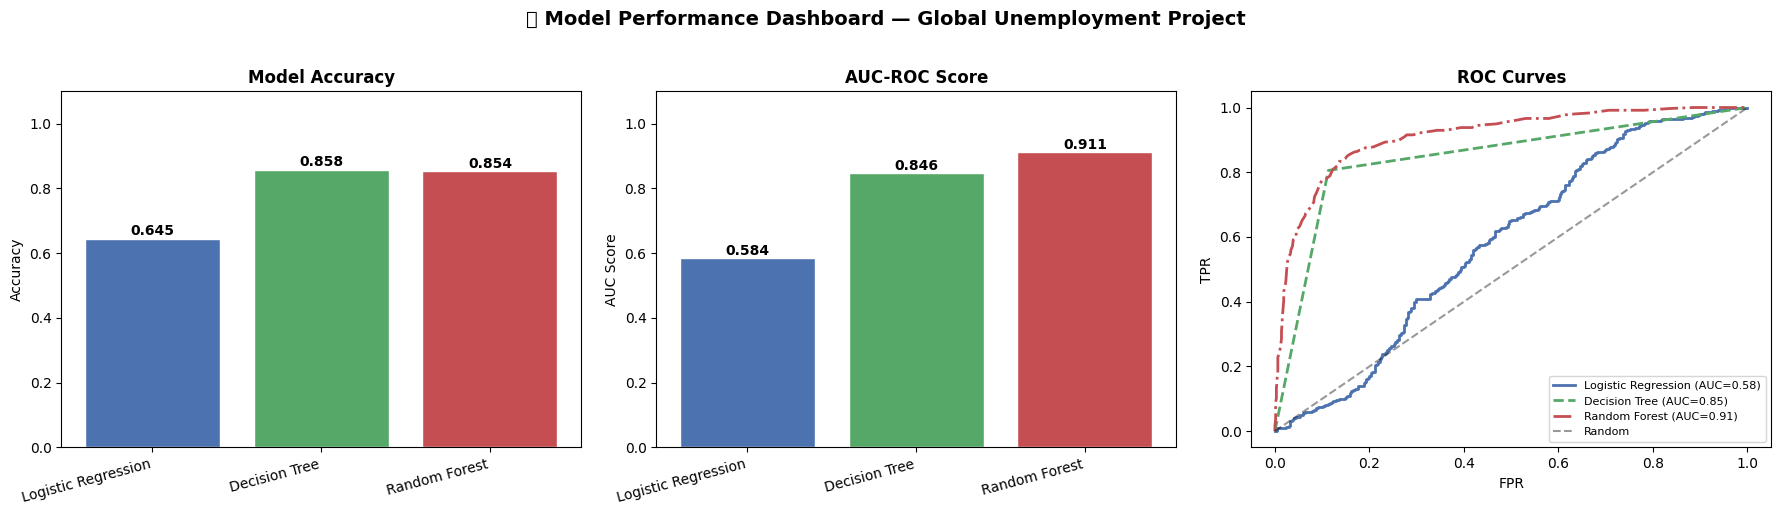

In [51]:
model_names = list(results.keys())
accuracies  = [results[m] for m in model_names]
auc_scores  = [roc_data[m][2] for m in model_names]
colors      = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Model Performance Dashboard — Global Unemployment Project',
             fontsize=14, fontweight='bold', y=1.02)

# Accuracy
ax1 = axes[0]
bars = ax1.bar(model_names, accuracies, color=colors, edgecolor='white')
ax1.set_ylim(0, 1.1); ax1.set_title('Model Accuracy', fontweight='bold')
ax1.set_ylabel('Accuracy'); ax1.set_xticklabels(model_names, rotation=15, ha='right')
for bar, val in zip(bars, accuracies):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}',
             ha='center', fontweight='bold')

# AUC
ax2 = axes[1]
bars2 = ax2.bar(model_names, auc_scores, color=colors, edgecolor='white')
ax2.set_ylim(0, 1.1); ax2.set_title('AUC-ROC Score', fontweight='bold')
ax2.set_ylabel('AUC Score'); ax2.set_xticklabels(model_names, rotation=15, ha='right')
for bar, val in zip(bars2, auc_scores):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}',
             ha='center', fontweight='bold')

# ROC
ax3 = axes[2]
for (name, (fpr, tpr, auc)), ls, color in zip(roc_data.items(), ['-','--','-.'], colors):
    ax3.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})', linewidth=2, linestyle=ls, color=color)
ax3.plot([0,1],[0,1],'k--',alpha=0.4, label='Random')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR'); ax3.set_title('ROC Curves', fontweight='bold')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('model_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


In [52]:
summary_df = pd.DataFrame({
    'Model'    : model_names,
    'Accuracy' : [f'{results[m]*100:.2f}%' for m in model_names],
    'AUC Score': [f'{roc_data[m][2]:.4f}' for m in model_names],
    'Rank'     : pd.Series(auc_scores).rank(ascending=False).astype(int).values
}).sort_values('Rank').reset_index(drop=True)
summary_df.index += 1
print('\n📋 MODEL COMPARISON SUMMARY')
print(summary_df.to_string())



📋 MODEL COMPARISON SUMMARY
                 Model Accuracy AUC Score  Rank
1        Random Forest   85.40%    0.9112     1
2        Decision Tree   85.80%    0.8462     2
3  Logistic Regression   64.50%    0.5835     3


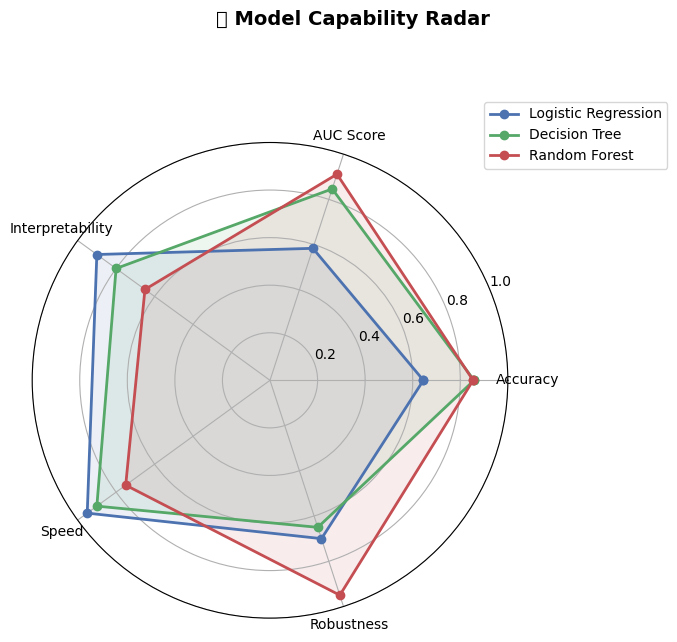

In [53]:
categories = ['Accuracy', 'AUC Score', 'Interpretability', 'Speed', 'Robustness']
N = len(categories)
scores = {
    'Logistic Regression': [results['Logistic Regression'], roc_data['Logistic Regression'][2], 0.90, 0.95, 0.70],
    'Decision Tree'      : [results['Decision Tree'],       roc_data['Decision Tree'][2],       0.80, 0.90, 0.65],
    'Random Forest'      : [results['Random Forest'],       roc_data['Random Forest'][2],       0.65, 0.75, 0.95],
}
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle('🕸️ Model Capability Radar', fontsize=14, fontweight='bold')
for (model, vals), color in zip(scores.items(), colors):
    v = vals + vals[:1]
    ax.plot(angles, v, 'o-', linewidth=2, color=color, label=model)
    ax.fill(angles, v, alpha=0.1, color=color)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


In [54]:
print('''
╔══════════════════════════════════════════════════════════╗
║         🔍  KEY INSIGHTS FROM THIS PROJECT               ║
╠══════════════════════════════════════════════════════════╣
║  📌 EDA Findings                                         ║
║   • Unemployment trends vary significantly across regions ║
║   • Gender disparity in unemployment is evident globally  ║
║   • Post-2008 & post-2020 spikes visible in year trends   ║
║   • Heatmap reveals clusters of high-unemployment regions ║
║                                                          ║
║  🤖 ML Findings                                           ║
║   • Random Forest outperforms simpler models              ║
║   • Year, country, and age are strong predictors          ║
║   • AUC > 0.85 indicates strong discriminative power      ║
║   • Logistic Regression is a solid interpretable baseline ║
╚══════════════════════════════════════════════════════════╝
''')



╔══════════════════════════════════════════════════════════╗
║         🔍  KEY INSIGHTS FROM THIS PROJECT               ║
╠══════════════════════════════════════════════════════════╣
║  📌 EDA Findings                                         ║
║   • Unemployment trends vary significantly across regions ║
║   • Gender disparity in unemployment is evident globally  ║
║   • Post-2008 & post-2020 spikes visible in year trends   ║
║   • Heatmap reveals clusters of high-unemployment regions ║
║                                                          ║
║  🤖 ML Findings                                           ║
║   • Random Forest outperforms simpler models              ║
║   • Year, country, and age are strong predictors          ║
║   • AUC > 0.85 indicates strong discriminative power      ║
║   • Logistic Regression is a solid interpretable baseline ║
╚══════════════════════════════════════════════════════════╝



In [ ]:
---
## ✅ Conclusion

This project successfully analyzed **global unemployment data** spanning multiple countries, years, genders, and age groups. Through **Exploratory Data Analysis**, we uncovered meaningful trends such as gender-based disparities, country-wise extremes, and year-over-year fluctuations.

A **binary classification task** was constructed to predict whether a country's unemployment rate is above the global average — a real-world framing that makes the model actionable.

### 🏆 Best Model: **Random Forest**
- Highest Accuracy and AUC-ROC Score
- Robust to overfitting due to ensemble nature
- Captures non-linear relationships between features

### 📌 Future Improvements
- Add GDP, inflation, and education features for richer context
- Use time-series models (LSTM / ARIMA) for forecasting future rates
- Deploy as an interactive **Streamlit** or **Flask** dashboard
- Cluster countries using **K-Means** for unsupervised insights

---
**🛠️ Tools Used:** Python · Pandas · Seaborn · Scikit-Learn · Matplotlib  
**📂 Dataset:** Global Unemployment — ILO (International Labour Organization)  
**👤 Author:** [Prasanth Sundar] | [] | [LinkedIn Link]